In [37]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pl.Config.set_tbl_rows(15)

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


In [38]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
variant_class = 'missense'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [39]:
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

rare_variant_annotations = config["rare_variant_annotations"]

all_annotation_list = []
color_dict = {}
label_dict = {}
direction_dict = {}

# Optional: for a Polars DataFrame
annotations = []
annotation_colors = []
annotation_labels = []
annotation_dirs = []

for category, annos in rare_variant_annotations.items():
    for anno, props in annos.items():
        # validate presence of keys
        if "color" not in props or "label" not in props:
            raise ValueError(
                f"Annotation '{anno}' in category '{category}' must define both 'color' and 'label'."
            )

        # Save lists/dicts
        all_annotation_list.append(anno)
        color_dict[anno] = props["color"]
        label_dict[anno] = props["label"]
        direction = props.get("direction", 1)
        direction_dict[anno] = direction

        # For Polars DataFrame
        annotations.append(anno)
        annotation_colors.append(props["color"])
        annotation_labels.append(props["label"])
        annotation_dirs.append(direction)

# Create Polars DataFrame
anno_config_df = pl.DataFrame({
    "annotation": annotations,
    "annotation_dir": annotation_dirs,
    "color": annotation_colors,
    "label": annotation_labels
})

print("Annotations:", all_annotation_list)
print("Colors:", color_dict)
print("Labels:", label_dict)
print("Directions:", direction_dict)
print("\nPolars DataFrame:")
print(anno_config_df)


Annotations: ['cadd_raw', 'am_pathogenicity', 'esmscoremissense', 'gpn_score', 'zooverphylop', 'verphylop', 'relative_cds_position']
Colors: {'cadd_raw': '#1f77b4', 'am_pathogenicity': '#e76e5b', 'esmscoremissense': '#feb72d', 'gpn_score': '#942c80', 'zooverphylop': '#6a1c81', 'verphylop': '#440154', 'relative_cds_position': '#b5de2b'}
Labels: {'cadd_raw': 'CADD Raw', 'am_pathogenicity': 'AlphaMissense', 'esmscoremissense': 'ESM1v', 'gpn_score': 'GPN-MSA', 'zooverphylop': 'Zoonomia vertebrate\nPhyloP', 'verphylop': 'Vertebrate PhyloP', 'relative_cds_position': 'Relative CDS\nPosition'}
Directions: {'cadd_raw': 1, 'am_pathogenicity': 1, 'esmscoremissense': -1, 'gpn_score': -1, 'zooverphylop': 1, 'verphylop': 1, 'relative_cds_position': -1}

Polars DataFrame:
shape: (7, 4)
┌───────────────────────┬────────────────┬─────────┬─────────────────────┐
│ annotation            ┆ annotation_dir ┆ color   ┆ label               │
│ ---                   ┆ ---            ┆ ---     ┆ ---            

In [24]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/variant_classes/genebass1e6_{variant_class.lower()}_variants.parquet")

cols = anno.collect_schema().names()
rename_map = {}
for c in cols:
    new = c.lower()
    if new.startswith('cadd_') and (not new.startswith('cadd_raw') and not new.startswith('cadd_phred')):
        new = new[len('cadd_'):]
    rename_map[c] = new

anno = anno.rename(rename_map)
anno.head().collect()

chrom,pos,ref,alt,id,col,gene,distance,polyphen,cadd_raw,am_pathogenicity,spliceai_delta_score,consequence_3_prime_utr_variant,consequence_5_prime_utr_variant,consequence_nmd_transcript_variant,consequence_coding_sequence_variant,consequence_downstream_gene_variant,consequence_frameshift_variant,consequence_inframe_deletion,consequence_inframe_insertion,consequence_intergenic_variant,consequence_intron_variant,consequence_missense_variant,consequence_non_coding_transcript_exon_variant,consequence_non_coding_transcript_variant,consequence_protein_altering_variant,consequence_splice_acceptor_variant,consequence_splice_donor_5th_base_variant,consequence_splice_donor_region_variant,consequence_splice_donor_variant,consequence_splice_polypyrimidine_tract_variant,consequence_splice_region_variant,consequence_start_lost,consequence_start_retained_variant,consequence_stop_gained,consequence_stop_lost,consequence_stop_retained_variant,…,mmsp_donorintron_is_nan,dist2mutation_is_nan,freq100bp_is_nan,rare100bp_is_nan,sngl100bp_is_nan,freq1000bp_is_nan,rare1000bp_is_nan,sngl1000bp_is_nan,freq10000bp_is_nan,rare10000bp_is_nan,sngl10000bp_is_nan,ensembleregulatoryfeature_is_nan,dbscsnv-ada_score_is_nan,dbscsnv-rf_score_is_nan,remapoverlaptf_is_nan,remapoverlapcl_is_nan,esmscoremissense_is_nan,esmscoreinframe_is_nan,esmscoreframeshift_is_nan,regseq0_is_nan,regseq1_is_nan,regseq2_is_nan,regseq3_is_nan,regseq4_is_nan,regseq5_is_nan,regseq6_is_nan,regseq7_is_nan,aparent2_is_nan,zoopriphylop_is_nan,zooverphylop_is_nan,zoorocc_is_nan,zoouce_is_nan,roulette-filter_is_nan,roulette-mr_is_nan,roulette-ar_is_nan,cadd_rawscore_is_nan,cadd_phred_is_nan
str,i32,str,str,str,i32,str,i32,f32,f32,f32,f32,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""chr14""",31133286,"""C""","""T""","""chr14:31133286:C:T""",64645190,"""ENSG00000092148""",0,0.997,5.175947,0.9774,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
"""chr14""",31133294,"""C""","""T""","""chr14:31133294:C:T""",64645192,"""ENSG00000092148""",0,0.589,5.305631,0.7619,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
"""chr14""",31133379,"""G""","""A""","""chr14:31133379:G:A""",64645208,"""ENSG00000092148""",0,0.964,4.69957,0.9854,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
"""chr14""",31133571,"""T""","""C""","""chr14:31133571:T:C""",64645274,"""ENSG00000092148""",0,0.999,5.012453,0.9987,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0
"""chr14""",31133594,"""T""","""G""","""chr14:31133594:T:G""",64645279,"""ENSG00000092148""",0,0.935,3.866917,0.9953,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


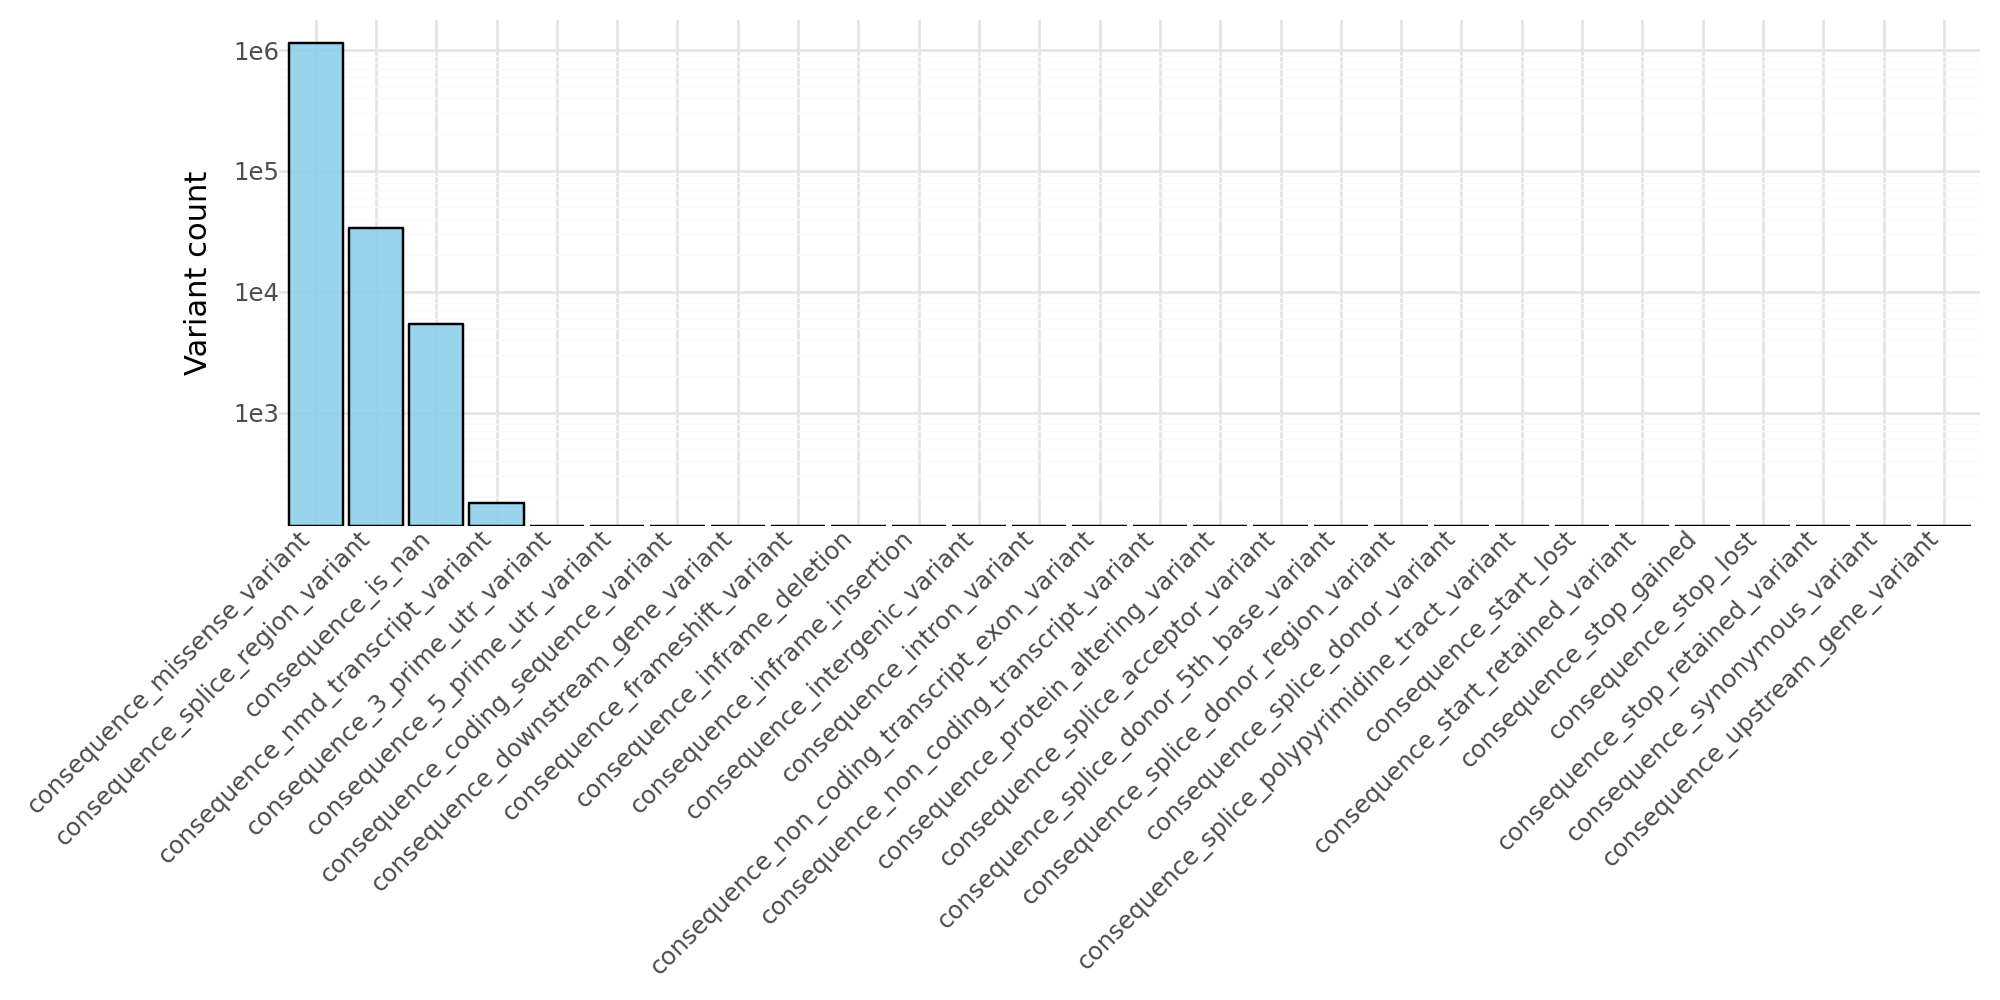

In [25]:
cons_annos = [c for c in anno.collect_schema().names() if c[:12] == 'consequence_']

# Plot counts of variant consequences
counts = (
    anno.select(cons_annos)
    .sum()
    .collect()
    .unpivot(variable_name='Consequence', value_name='Count')
    .sort('Count', descending=True)
    .to_pandas()
)

# preserve order for plotting
counts['Consequence'] = pd.Categorical(counts['Consequence'], categories=counts['Consequence'].tolist(), ordered=True)

(
    ggplot(counts, aes(x='Consequence', y='Count')) +
    geom_col(fill='skyblue', color='black', alpha=0.85) +
    theme_minimal() +
    labs(x='', y='Variant count') +
    scale_x_discrete(limits=counts['Consequence'].cat.categories.tolist()) +
    scale_y_log10() +
    theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(10, 5))
)

In [26]:
existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = anno.select(
    set(['id', 'region']).union(set(existing_annos))
).collect(engine='streaming')

print('filtered anno')
anno #.head().collect()

filtered anno


gpn_score,region,am_pathogenicity,zooverphylop,cadd_raw,verphylop,id,relative_cds_position,esmscoremissense
f32,str,f32,f32,f32,f32,str,f32,f32
-11.06,"""ENSG00000092148""",0.9774,8.894,5.175947,7.194,"""chr14:31133286:C:T""",0.49,-4.355
-9.56,"""ENSG00000092148""",0.7619,8.894,5.305631,7.194,"""chr14:31133294:C:T""",0.49,-3.633
-5.15,"""ENSG00000092148""",0.9854,2.545,4.69957,1.701,"""chr14:31133379:G:A""",0.48,-6.029
-10.32,"""ENSG00000092148""",0.9987,6.354,5.012453,8.849,"""chr14:31133571:T:C""",0.47,-6.444
-6.87,"""ENSG00000092148""",0.9953,4.213,3.866917,3.126,"""chr14:31133594:T:G""",0.47,-2.537
-10.43,"""ENSG00000092148""",0.3498,6.354,4.594253,5.848,"""chr14:31133643:T:A""",0.46,-4.649
-5.93,"""ENSG00000092148""",0.0808,4.105,2.886665,2.463,"""chr14:31133647:G:T""",0.46,-3.436
-10.97,"""ENSG00000092148""",0.4474,6.354,4.591865,8.849,"""chr14:31133652:T:C""",0.46,-3.991
…,…,…,…,…,…,…,…,…


In [27]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)

print('melted anno')

melted_anno['id'].n_unique(), melted_anno.shape[0]

melted anno


(1141014, 8001609)

In [28]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()
unique_phenotypes

phenotype
str
"""lymphocyte_count_int"""
"""pulse_rate_automated_reading_i…"
"""trunk_fatfree_mass_int"""
"""mean_reticulocyte_volume_int"""
"""leg_predicted_mass_left_int"""
"""age_last_used_hormonereplaceme…"
"""red_blood_cell_erythrocyte_cou…"
"""whole_body_water_mass_int"""
…


In [29]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(unique_phenotypes)) &
    (pl.col('region').is_in(anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)

gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner').with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)

gene_trait_df

/tmp/ipykernel_98749/2131262527.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type,beta,beta_dir
str,str,str,str,str,f64,f64
"""ENSG00000151414""","""ENSG00000151414""","""NEK7""","""lymphocyte_percentage_int""","""continuous""",-0.34187,-1.0
"""ENSG00000068976""","""ENSG00000068976""","""PYGM""","""lymphocyte_percentage_int""","""continuous""",0.0320271,1.0
"""ENSG00000160593""","""ENSG00000160593""","""JAML""","""lymphocyte_percentage_int""","""continuous""",0.189942,1.0
"""ENSG00000173575""","""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""",0.0271693,1.0
"""ENSG00000240505""","""ENSG00000240505""","""TNFRSF13B""","""lymphocyte_percentage_int""","""continuous""",-0.059283,-1.0
"""ENSG00000196712""","""ENSG00000196712""","""NF1""","""lymphocyte_percentage_int""","""continuous""",-0.792415,-1.0
"""ENSG00000073605""","""ENSG00000073605""","""GSDMB""","""lymphocyte_percentage_int""","""continuous""",-0.067824,-1.0
"""ENSG00000183153""","""ENSG00000183153""","""GJD3""","""lymphocyte_percentage_int""","""continuous""",-0.015211,-1.0
…,…,…,…,…,…,…


In [30]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(1045, 3055)

In [ ]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together.
# Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .drop_nulls()
    
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("ordinal")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr("mean_pheno_value_rank", "annotation_score_rank", propagate_nans=True).alias("correlation")
    )
    
    # E. Add the final column lazily
    .with_columns(
        pl.col("correlation").abs().alias("abs_corr")
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

# --- 3. Join with beta directions and annotation directions ---
correlation_df = correlation_df.join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
).with_columns(
    (pl.col('correlation')*pl.col('beta_dir')*pl.col('annotation_dir')).alias('corr_beta')
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Executing the full lazy plan with the streaming engine...
Final DataFrame shape: (21385, 13)


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,beta,beta_dir,annotation_dir,color,label,corr_beta
str,str,str,str,u64,f64,f64,f64,f64,i64,str,str,f64
"""ENSG00000143257""","""NR1I3""","""direct_bilirubin_int""","""esmscoremissense""",94,-0.144818,0.144818,0.156029,1.0,-1,"""#feb72d""","""ESM1v""",0.144818
"""ENSG00000168140""","""VASN""","""alkaline_phosphatase_int""","""gpn_score""",260,0.098816,0.098816,0.0734599,1.0,-1,"""#942c80""","""GPN-MSA""",-0.098816
"""ENSG00000112343""","""TRIM38""","""mean_corpuscular_volume_int""","""verphylop""",136,0.185549,0.185549,-0.055847,-1.0,1,"""#440154""","""Vertebrate PhyloP""",-0.185549
"""ENSG00000125149""","""C16orf70""","""arm_predicted_mass_right_int""","""am_pathogenicity""",80,-0.016057,0.016057,-0.062209,-1.0,1,"""#e76e5b""","""AlphaMissense""",0.016057
"""ENSG00000204525""","""HLA-C""","""lymphocyte_count_int""","""zooverphylop""",66,-0.276401,0.276401,0.0565656,1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",-0.276401
"""ENSG00000112077""","""RHAG""","""high_light_scatter_reticulocyt…","""relative_cds_position""",106,0.175081,0.175081,0.73951,1.0,-1,"""#b5de2b""","""Relative CDS Position""",-0.175081
"""ENSG00000104044""","""OCA2""","""age_started_wearing_glasses_or…","""esmscoremissense""",258,0.120421,0.120421,-0.116217,-1.0,-1,"""#feb72d""","""ESM1v""",0.120421
"""ENSG00000117400""","""MPL""","""mean_platelet_thrombocyte_volu…","""zooverphylop""",159,0.014906,0.014906,-0.125828,-1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",-0.014906
…,…,…,…,…,…,…,…,…,…,…,…,…


In [32]:
# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

Inconsistent (region, phenotype) pairs: 0


In [33]:
neg_gene_trait = correlation_df.filter(pl.col('corr_beta')<0).group_by(
    ['gene_name', 'phenotype']
).agg(pl.len()).sort('len', descending=True).filter(pl.col('len')>=5)

pos_gene_trait = correlation_df.filter(pl.col('corr_beta')>0).group_by(
    ['gene_name', 'phenotype']
).agg(pl.len()).sort('len', descending=True).filter(pl.col('len')>=4)

# pos_gene_trait.write_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym_concordant.parquet')
pos_gene_trait

gene_name,phenotype,len
str,str,u64
"""HBB""","""mean_corpuscular_volume_int""",7
"""EPB42""","""reticulocyte_count_int""",7
"""DDR2""","""standing_height_int""",7
"""SPP2""","""phosphate_int""",7
"""LDLR""","""apolipoprotein_b_int""",7
"""SPHK1""","""white_blood_cell_leukocyte_cou…",7
"""ZFAT""","""sitting_height_int""",7
"""SLC22A12""","""urate_int""",7
…,…,…


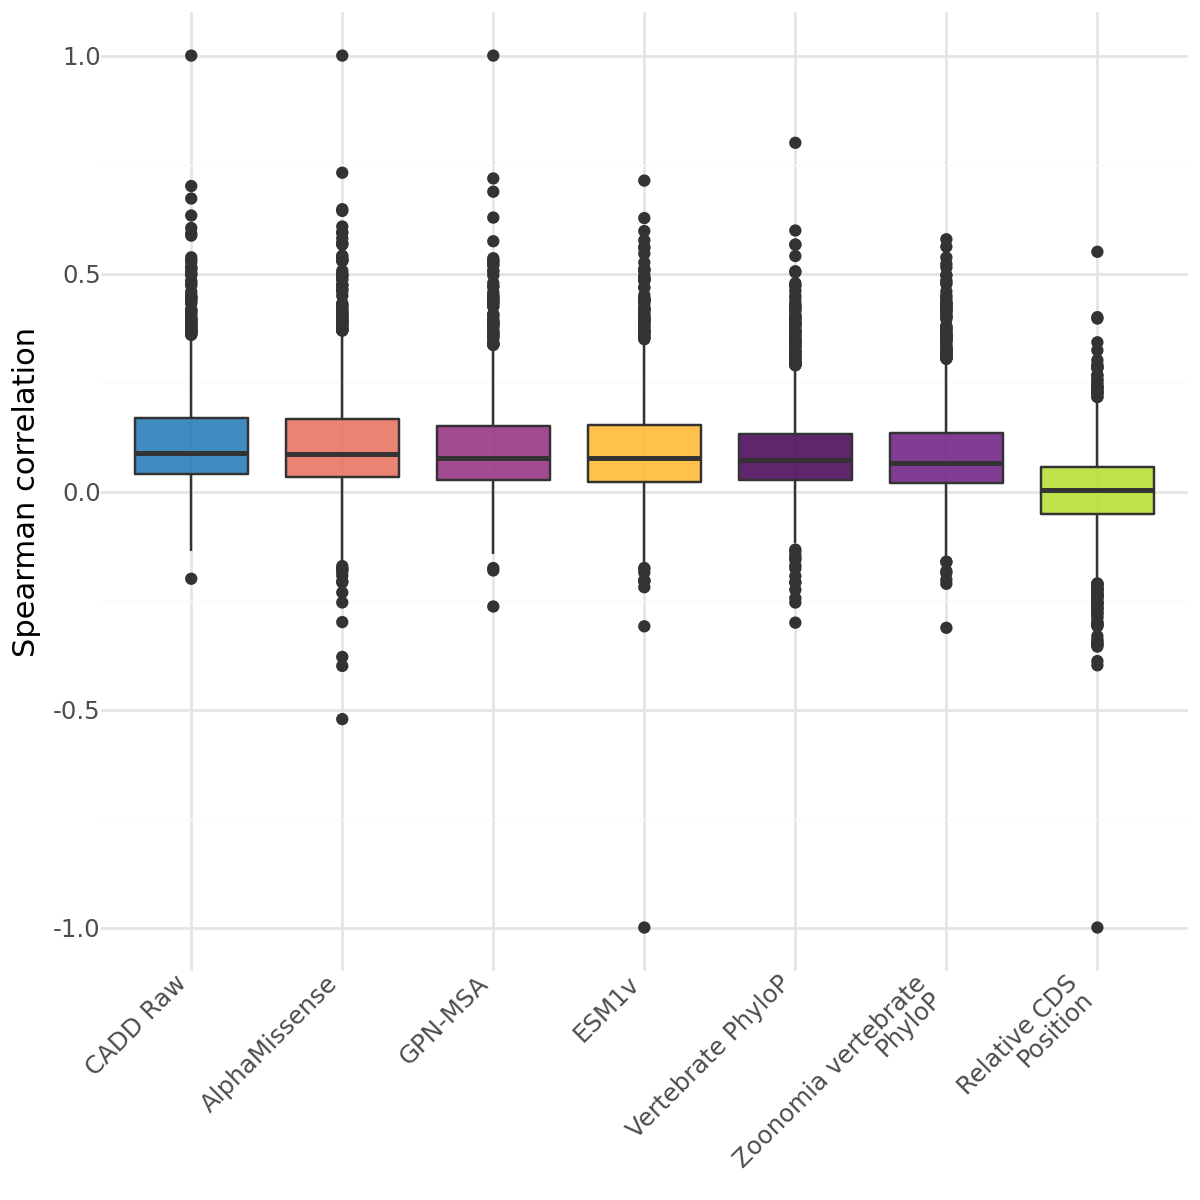

In [40]:
pos_corr_df = correlation_df.join(pos_gene_trait, on=['gene_name', 'phenotype'], how='inner')
pos_corr_df

med_df = pos_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(pos_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)


# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.85) +
    theme_minimal() +
    # scale_y_sqrt() +
    scale_fill_manual(values=color_dict) +   # strict, always from config
    # scale_x_discrete(labels=label_dict) +    # plottable names
    labs(
        x="",
        y="Spearman correlation"
    ) +
    theme(
        figure_size=(6, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [ ]:
import itertools
from scipy.stats import wilcoxon

annotations = pos_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = pos_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = pos_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df

/tmp/ipykernel_98749/790602733.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""am_pathogenicity""","""cadd_raw""",2107,1.082078e6,0.328747
"""verphylop""","""zooverphylop""",2107,1.064484e6,0.100256
"""gpn_score""","""esmscoremissense""",2107,1.095464e6,0.593076


## Odds ratio plot

In [46]:
correlation_df.filter(pl.col('n_variants')>100)
# pos_corr_df.filter(pl.col('n_variants')>100)

region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr,beta,beta_dir,annotation_dir,color,label,corr_beta
str,str,str,str,u64,f64,f64,f64,f64,i64,str,str,f64
"""ENSG00000168140""","""VASN""","""alkaline_phosphatase_int""","""gpn_score""",260,0.098816,0.098816,0.0734599,1.0,-1,"""#942c80""","""GPN-MSA""",-0.098816
"""ENSG00000112343""","""TRIM38""","""mean_corpuscular_volume_int""","""verphylop""",136,0.185549,0.185549,-0.055847,-1.0,1,"""#440154""","""Vertebrate PhyloP""",-0.185549
"""ENSG00000112077""","""RHAG""","""high_light_scatter_reticulocyt…","""relative_cds_position""",106,0.175081,0.175081,0.73951,1.0,-1,"""#b5de2b""","""Relative CDS Position""",-0.175081
"""ENSG00000104044""","""OCA2""","""age_started_wearing_glasses_or…","""esmscoremissense""",258,0.120421,0.120421,-0.116217,-1.0,-1,"""#feb72d""","""ESM1v""",0.120421
"""ENSG00000117400""","""MPL""","""mean_platelet_thrombocyte_volu…","""zooverphylop""",159,0.014906,0.014906,-0.125828,-1.0,1,"""#6a1c81""","""Zoonomia vertebrate PhyloP""",-0.014906
"""ENSG00000204469""","""PRRC2A""","""platelet_distribution_width_in…","""cadd_raw""",761,-0.06714,0.06714,-0.076719,-1.0,1,"""#1f77b4""","""CADD Raw""",0.06714
"""ENSG00000165702""","""GFI1B""","""eosinophill_count_int""","""am_pathogenicity""",108,0.100956,0.100956,0.487639,1.0,1,"""#e76e5b""","""AlphaMissense""",0.100956
"""ENSG00000080031""","""PTPRH""","""reticulocyte_percentage_int""","""esmscoremissense""",357,0.017339,0.017339,-0.032778,-1.0,-1,"""#feb72d""","""ESM1v""",0.017339
…,…,…,…,…,…,…,…,…,…,…,…,…


In [ ]:
pos_pheno_anno = pheno_anno.join(pos_gene_trait, on=['gene_name', 'phenotype'], how='inner')

ct_df = pos_pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
).join(
    gene_trait_df[['region', 'phenotype', 'beta', 'beta_dir']], on=['region', 'phenotype']
).join(
    anno_config_df, on='annotation'
)

xtm_df = pos_pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")


xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_dircrtd"),
    (pl.col("annotation_score")*pl.col("annotation_dir")).alias("annotation_score_dircrtd")
)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value_dircrtd', 'annotation_score_dircrtd']
]

# Apply the window expressions with .with_columns()
xtm_df = xtm_df.with_columns(rank_expressions).with_columns(
    (pl.col("mean_pheno_value_dircrtd_rank") / pl.col("n_variants")).alias("mean_pheno_value_dircrtd_ptile"),
    (pl.col("annotation_score_dircrtd_rank") / pl.col("n_variants")).alias("annotation_score_dircrtd_ptile")
)

xtm_df = xtm_df.with_columns(
    pl.when(pl.col("mean_pheno_value_dircrtd_ptile") >= 0.95)
    .then(1)
    .otherwise(0)
    .alias("mean_pheno_value_dircrtd_binary"),
)

xtm_df

In [ ]:
or_df_list = []
for p_itr in tqdm(range(100)):
    ptile_cutoff = 0.5 + p_itr/200
    # ptile_cutoff = p_itr/100

    or_temp = xtm_df.group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        ((pl.col("mean_pheno_value_dircrtd_binary")==1) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_dis_above_cutoff"),
        ((pl.col("mean_pheno_value_dircrtd_binary")==0) & (pl.col("annotation_score_dircrtd_ptile")>=ptile_cutoff)).sum().alias("n_not_dis_above_cutoff"),
        (pl.col("mean_pheno_value_dircrtd_binary")==1).sum().alias("total_dis"),
        (pl.col("mean_pheno_value_dircrtd_binary")==0).sum().alias("total_not_dis")
    ).with_columns(
        pl.lit(ptile_cutoff).alias("ptile_cutoff"),
        (pl.col("total_dis")+pl.col("total_not_dis")).alias("n_variants"),
        (((pl.col("n_dis_above_cutoff")+1) / (pl.col("n_not_dis_above_cutoff")+1))/(pl.col("total_dis")/pl.col("total_not_dis"))).alias("odds_ratio"),
    )

    or_df_list.append(or_temp)

or_df = pl.concat(or_df_list)
or_df

In [ ]:
plot_df = or_df.group_by(
    ['annotation', 'ptile_cutoff']
).agg(
    pl.col('odds_ratio').mean()
)

(
    ggplot(plot_df, aes(x='ptile_cutoff', y='odds_ratio', color='annotation')) +
    geom_line(size=1.25) +
    theme_minimal() +
    scale_y_log10() +
    # scale_x_log10() +
    scale_color_manual(values=color_dict) +
    labs(
        x='Percentile Cutoff',
        y='Average Odds Ratio'
    ) +
    theme(
        figure_size=(6, 4),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Single gene-trait association plot

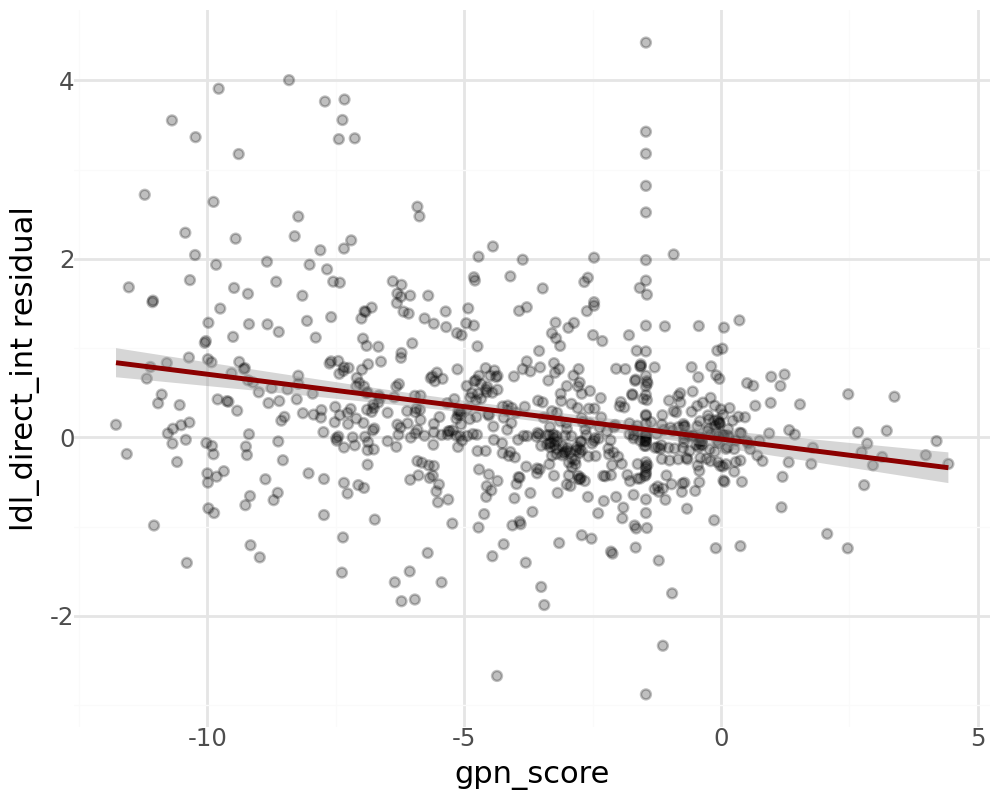

In [10]:
method = 'pearson'
annotation = 'gpn_score'
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)